In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
def recomendar_partidos(df_partidos, perfil_usuario):
    """
    Calcula un score de recomendación para cada partido basado en las preferencias
    del usuario, sus horarios disponibles, y métricas PCA (Acepta pesos negativos).
    """
    df = df_partidos.copy()
    
    # =====================================================================
    # PASO 1: Calcular la característica dinámica (Horario Libre y Días)
    # =====================================================================
    def verificar_disponibilidad(row):
        utc_offset = perfil_usuario.get('utc_offset', -3) 
        hora_utc = row['match_hora_utc']
        dia_utc = row['day_of_week_num']
        
        hora_local_bruta = hora_utc + utc_offset
        hora_1 = hora_local_bruta % 24
        
        if hora_local_bruta >= 24:
            dia_1 = (dia_utc + 1) % 7
        elif hora_local_bruta < 0:
            dia_1 = (dia_utc - 1) % 7
        else:
            dia_1 = dia_utc
            
        hora_2 = (hora_1 + 1) % 24 
        dia_2 = (dia_1 + 1) % 7 if hora_2 < hora_1 else dia_1
        
        puede_ver_primer_tiempo = hora_1 in perfil_usuario['horario_libre'].get(dia_1, [])
        puede_ver_segundo_tiempo = hora_2 in perfil_usuario['horario_libre'].get(dia_2, [])
        
        if puede_ver_primer_tiempo and puede_ver_segundo_tiempo:
            return 1.0  
        elif puede_ver_primer_tiempo or puede_ver_segundo_tiempo:
            return 0.5  
        else:
            return 0.0  
            
    df['feature_disponibilidad'] = df.apply(verificar_disponibilidad, axis=1)

    # =====================================================================
    # PASO 2: Extraer y NORMALIZAR (Con Valores Absolutos)
    # =====================================================================
    pesos_crudos = perfil_usuario.get('pesos', {}).copy()
    pesos_crudos['w_horario_libre'] = 20.0  # El horario libre siempre se asume positivo
    
    # 1. Sumamos los valores absolutos para armar la torta matemática
    suma_total = sum(abs(v) for v in pesos_crudos.values())
    if suma_total == 0: suma_total = 1 
    
    # 2. Pesos normalizados (porcentaje de importancia real, siempre positivo)
    pesos_norm = {k: abs(v) / suma_total for k, v in pesos_crudos.items()}
    
    # 3. Guardamos la "intención" del usuario (1 si es positivo, -1 si es negativo)
    signos = {k: (1 if v >= 0 else -1) for k, v in pesos_crudos.items()}

    # --- C. Feature de Nacionalidad ---
    pais_usuario = perfil_usuario.get('nacionalidad', '')
    df['feature_nacionalidad'] = (
        (df['home_team'] == pais_usuario) | (df['away_team'] == pais_usuario)
    ).astype(float)
    
    # =====================================================================
    # PASO 3: Calcular el Score Final (Con Ruteo de Signos)
    # =====================================================================
    # Helper: Multiplica el peso por la característica correcta según el signo
    def aplicar_logica(peso_key, feature_directa, feature_inversa):
        peso = pesos_norm.get(peso_key, 0)
        signo = signos.get(peso_key, 1)
        # Si puso un negativo, premiamos lo opuesto
        return peso * (feature_directa if signo > 0 else feature_inversa)

    df['Score_Recomendacion'] = (
        # 1. Nacionalidad: Si es negativo, odia al equipo y premia que NO juegue
        aplicar_logica('w_nacionalidad', df['feature_nacionalidad'], 1 - df['feature_nacionalidad']) +        
        
        # 2. Calidad ELO: Si es negativo, quiere equipos malos históricamente
        aplicar_logica('w_calidad_elo', df['ELO_match_rating_scaled'], 1 - df['ELO_match_rating_scaled']) +      
        
        # 3. Paridad ELO: Recordar que ELO_diff es disparidad. 
        # (Directa: 1-diff para paridad | Inversa: diff para goleadas)
        aplicar_logica('w_paridad_elo', 1 - df['ELO_diff_scaled'], df['ELO_diff_scaled']) +       
        
        # 4. Calidad FIFA: Si es negativo, quiere jugadores desconocidos/bronce
        aplicar_logica('w_calidad_fifa', df['PC2_Calidad_scaled'], 1 - df['PC2_Calidad_scaled']) +                  
        
        # 5. Paridad FIFA: Recordar que PC1 es disparidad.
        # (Directa: 1-PC1 para paridad | Inversa: PC1 para goleadas)
        aplicar_logica('w_paridad_fifa', 1 - df['PC1_Disparidad_scaled'], df['PC1_Disparidad_scaled']) +            
        
        # 6. Fin de semana: Si es negativo, quiere partidos de Lunes a Viernes
        aplicar_logica('w_fin_de_semana', df['is_weekend'], 1 - df['is_weekend']) +                  
        
        # 7. Horario libre (Fijo positivo)
        (pesos_norm.get('w_horario_libre', 0) * df['feature_disponibilidad'])     
    )

    # =====================================================================
    # PASO 4: Clasificación por Categorías (Híbrido)
    # =====================================================================
    q_alta = df['Score_Recomendacion'].quantile(0.85)
    q_media = df['Score_Recomendacion'].quantile(0.50)
    
    p_alta = max(q_alta, 0.65)  
    p_media = max(q_media, 0.45) 
    
    def categorizar_partido(score):
        if score >= p_alta:
            return "Imperdible 🌟"
        elif score >= p_media:
            return "Vale la pena 📺"
        else:
            return "Para ver el resumen 📱"
            
    df['Categoria'] = df['Score_Recomendacion'].apply(categorizar_partido)
    
    # =====================================================================
    # PASO 5: Ordenar
    # =====================================================================
    df_recomendado = df.sort_values(by='Score_Recomendacion', ascending=False)
    
    return df_recomendado

In [8]:
matriz_partidos = pd.read_csv("../data/matriz_partidos_scaled_pca.csv", index_col="id_partido")
matriz_partidos

,home_team,away_team,match_number,group_name,is_decisive,day_of_week_num,is_weekend,ELO_match_rating,ELO_diff,home_value,...,match_value_diff,match_hora_utc,ELO_match_rating_scaled,ELO_diff_scaled,match_value_scaled,match_value_diff_scaled,hora_utc_scaled,day_of_week_scaled,PC1_Disparidad_scaled,PC2_Calidad_scaled
id_partido,,,,,,,,,,,,,,,,,,,,,
1,Korea Republic,Czechia,2,A,0,4,0,3478,26,143.400,...,53.025,2,0.484417,0.022135,0.469576,0.448777,0.086957,0.666667,0.035209,0.316566
2,Mexico,South Africa,1,A,0,3,0,3382,334,85.600,...,32.900,19,0.398931,0.423177,0.205817,0.370770,0.826087,0.500000,0.348103,0.237827
3,Czechia,South Africa,25,A,0,3,0,3250,202,196.425,...,143.725,16,0.281389,0.251302,0.378366,0.613715,0.695652,0.500000,0.351705,0.224566
4,Mexico,Korea Republic,28,A,0,4,0,3610,106,85.600,...,57.800,1,0.601959,0.126302,0.353639,0.462953,0.043478,0.666667,0.031607,0.329827
5,South Africa,Korea Republic,54,A,1,3,0,3276,228,52.700,...,90.700,1,0.304541,0.285156,0.308133,0.537336,0.043478,0.500000,0.311323,0.173496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,England,Croatia,22,L,0,2,0,3950,90,1315.000,...,958.700,20,0.904720,0.105469,0.938463,0.930370,0.869565,0.333333,0.148335,0.913781
69,Panama,England,67,L,1,5,1,3757,283,32.850,...,1282.150,21,0.732858,0.356771,0.875099,0.978988,0.913043,0.833333,0.649233,0.785739
70,Ghana,Panama,21,L,0,2,0,3242,232,295.175,...,262.325,23,0.274265,0.290365,0.459189,0.713904,1.000000,0.333333,0.309469,0.167526


In [30]:
# Definimos el arquetipo: Un fanático del buen fútbol parejo, que prioriza un poco 
# que caiga en su horario libre después de trabajar.
#PREGUNTAMOS QUE TANTO LE IMPORTA LA CALIDAD Y LA PARIDAD
peso_calidad_usuario = 80
peso_paridad_usuario = 60

usuario_ejemplo = {
    "nacionalidad": "Argentina",
    "utc_offset": -3,
    "pesos": {
        "w_nacionalidad": 35,
        "w_calidad_elo": peso_calidad_usuario/2,      # Pesa 30% el nivel general
        "w_paridad_elo": peso_paridad_usuario/2,      # Pesa 20% que sea peleado
        "w_calidad_fifa": peso_calidad_usuario/2,    # calidad de los partidos
        "w_paridad_fifa": peso_paridad_usuario/2,    # paridad de los partidos
        "w_fin_de_semana": 10    # Pesa 5% si es fin de semana
        #"w_horario_libre": 0.20     # Pesa 20% que caiga en su agenda 
        #"w_decisivo": 0.10          #Que tanto le importan los últimos partidos del grupo
    },
    "horario_libre": {
        0: [18, 19, 20, 21, 22], # Lunes a Viernes libre desde las 18:00
        1: [18, 19, 20, 21, 22],
        2: [18, 19, 20, 21, 22],
        3: [18, 19, 20, 21, 22],
        4: [18, 19, 20, 21, 22],
        5: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22], # Sábado libre desde mediodía
        6: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]  # Domingo libre desde mediodía
    }
}

In [31]:
df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_ejemplo)

df_recomendaciones.head(10)

,home_team,away_team,match_number,group_name,is_decisive,day_of_week_num,is_weekend,ELO_match_rating,ELO_diff,home_value,...,match_value_scaled,match_value_diff_scaled,hora_utc_scaled,day_of_week_scaled,PC1_Disparidad_scaled,PC2_Calidad_scaled,feature_disponibilidad,feature_nacionalidad,Score_Recomendacion,Categoria
id_partido,,,,,,,,,,,,,,,,,,,,,
66,Colombia,Portugal,71,K,1,5,1,3959,9,303.95,...,0.857331,0.868224,1.000000,0.833333,0.152206,0.938581,1.0,0.0,0.777982,Imperdible 🌟
46,Uruguay,Spain,66,H,1,5,1,4057,273,361.10,...,0.931471,0.921635,0.000000,0.833333,0.149122,0.931479,1.0,0.0,0.743771,Imperdible 🌟
34,Netherlands,Japan,11,F,0,6,1,3865,57,763.00,...,0.795754,0.820378,0.869565,1.000000,0.139202,0.798792,1.0,0.0,0.727131,Imperdible 🌟
56,Argentina,Austria,43,J,0,0,0,3940,286,765.50,...,0.794507,0.823495,0.739130,0.000000,0.098376,0.744501,0.0,1.0,0.716298,Imperdible 🌟
13,Brazil,Morocco,7,C,0,5,1,3805,163,909.20,...,0.827775,0.870621,0.956522,0.833333,0.030681,0.782355,1.0,0.0,0.709181,Imperdible 🌟
58,Argentina,Algeria,19,J,0,2,0,3856,370,765.50,...,0.785198,0.833712,0.043478,0.333333,0.227505,0.706678,0.5,1.0,0.708200,Imperdible 🌟
31,Netherlands,Sweden,35,F,0,5,1,3680,242,763.00,...,0.840476,0.750984,0.739130,0.833333,0.153313,0.891143,1.0,0.0,0.675690,Imperdible 🌟
29,Germany,Côte d'Ivoire,33,E,0,5,1,3599,247,1005.50,...,0.910973,0.817715,0.869565,0.833333,0.124686,0.871095,1.0,0.0,0.660941,Imperdible 🌟
68,England,Croatia,22,L,0,2,0,3950,90,1315.00,...,0.938463,0.930370,0.869565,0.333333,0.148335,0.913781,0.5,0.0,0.659151,Imperdible 🌟


🏆 TOP 10 PARTIDOS RECOMENDADOS:
Pesos: {'w_nacionalidad': 35, 'w_calidad_elo': 40.0, 'w_paridad_elo': 30.0, 'w_calidad_fifa': 40.0, 'w_paridad_fifa': 30.0, 'w_fin_de_semana': 10}

  home_team     away_team  Score_Recomendacion      Categoria  match_hora_utc  day_of_week_num
   Colombia      Portugal             0.777982   Imperdible 🌟              23                5
    Uruguay         Spain             0.743771   Imperdible 🌟               0                5
Netherlands         Japan             0.727131   Imperdible 🌟              20                6
  Argentina       Austria             0.716298   Imperdible 🌟              17                0
     Brazil       Morocco             0.709181   Imperdible 🌟              22                5
  Argentina       Algeria             0.708200   Imperdible 🌟               1                2
Netherlands        Sweden             0.675690   Imperdible 🌟              17                5
    Germany Côte d'Ivoire             0.660941   Imperdible 

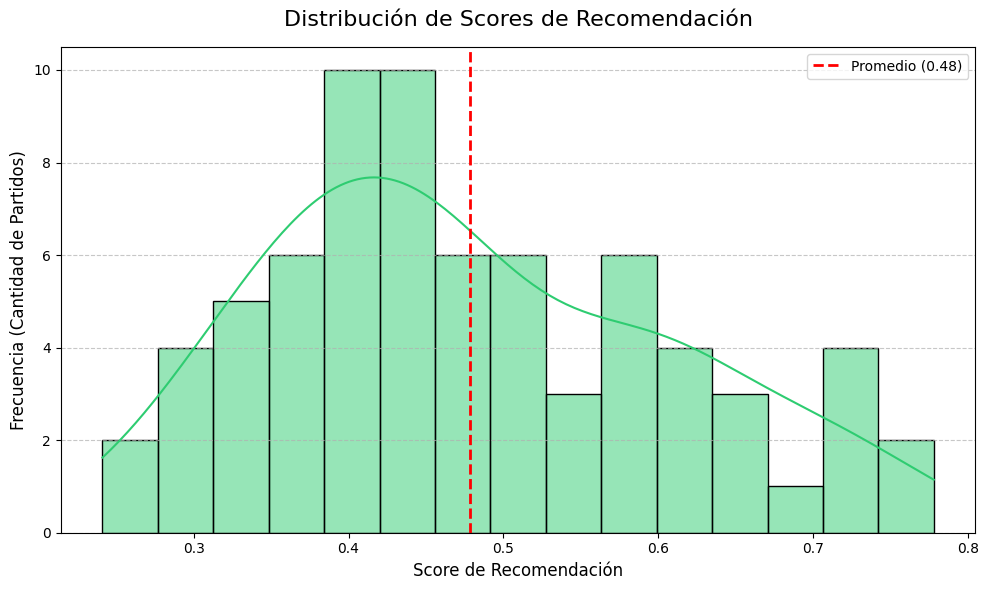

In [32]:
# =====================================================================
# 3. MOSTRAR RESULTADOS Y GRÁFICO
# =====================================================================

# Seleccionamos las columnas más importantes para ver el Top 10
columnas_vista = [
    'home_team', 'away_team', 'Score_Recomendacion', 
    'Categoria','match_hora_utc', 'day_of_week_num'
]

print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(f"Pesos: {usuario_ejemplo["pesos"]}\n")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

# --- Generar el gráfico de distribución ---
plt.figure(figsize=(10, 6))
sns.histplot(
    df_recomendaciones['Score_Recomendacion'], 
    bins=15, 
    kde=True, 
    color='#2ecc71', 
    edgecolor='black'
)

plt.title('Distribución de Scores de Recomendación', fontsize=16, pad=15)
plt.xlabel('Score de Recomendación', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Partidos)', fontsize=12)

# Línea marcando el promedio
promedio = df_recomendaciones['Score_Recomendacion'].mean()
plt.axvline(promedio, color='red', linestyle='dashed', linewidth=2, label=f'Promedio ({promedio:.2f})')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [33]:
df_recomendaciones["Categoria"].value_counts()

Categoria
Para ver el resumen 📱    36
Vale la pena 📺           27
Imperdible 🌟              9
Name: count, dtype: int64

In [28]:
usuario_fanatico = {
    "nacionalidad": "Mexico",
    "pesos": {
        "w_nacionalidad": 100,  # Importancia absoluta
        "w_calidad_elo": 0,
        "w_paridad_elo": 0,
        "w_calidad_fifa": 0,    
        "w_paridad_fifa": 0,   
        "w_fin_de_semana": 0
        #"w_horario_libre": 0,
        #"w_decisivo": 0
    },
    "horario_libre": {
        # Libre las 24hs del día (simulamos que no le importa el horario)
        0: list(range(0, 24)), 1: list(range(0, 24)), 2: list(range(0, 24)),
        3: list(range(0, 24)), 4: list(range(0, 24)), 5: list(range(0, 24)), 
        6: list(range(0, 24))
    }
}

df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_fanatico)
print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

🏆 TOP 10 PARTIDOS RECOMENDADOS:
     home_team          away_team  Score_Recomendacion             Categoria  match_hora_utc  day_of_week_num
        Mexico       South Africa             1.000000          Imperdible 🌟              19                3
        Mexico     Korea Republic             1.000000          Imperdible 🌟               1                4
       Czechia             Mexico             1.000000          Imperdible 🌟               1                3
Korea Republic            Czechia             0.166667 Para ver el resumen 📱               2                4
       Czechia       South Africa             0.166667 Para ver el resumen 📱              16                3
  South Africa     Korea Republic             0.166667 Para ver el resumen 📱               1                3
        Canada Bosnia-Herzegovina             0.166667 Para ver el resumen 📱              19                4
   Switzerland Bosnia-Herzegovina             0.166667 Para ver el resumen 📱            

In [14]:
df_recomendaciones["Categoria"].value_counts()

Categoria
Para ver el resumen 📱    69
Imperdible 🌟              3
Name: count, dtype: int64

In [27]:
#PREGUNTAMOS QUE TANTO LE IMPORTA LA CALIDAD Y LA PARIDAD
peso_calidad_usuario = 50
peso_paridad_usuario = 50

usuario_casual = {
    "nacionalidad": "",
    "utc_offset": -3,
    "pesos": {
        "w_nacionalidad": 60,
        "w_calidad_elo": peso_calidad_usuario/2,      # Pesa 30% el nivel general
        "w_paridad_elo": peso_paridad_usuario/2,      # Pesa 20% que sea peleado
        "w_calidad_fifa": peso_calidad_usuario/2,    # calidad de los partidos
        "w_paridad_fifa": peso_paridad_usuario/2,    # paridad de los partidos
        "w_fin_de_semana": 10    # Pesa 5% si es fin de semana
        #"w_horario_libre": 0.20     # Pesa 20% que caiga en su agenda 
        #"w_decisivo": 0.10          #Que tanto le importan los últimos partidos del grupo
    },
    "horario_libre": {
        0: [], 1: [], 2: [], 3: [], 4: [], # Lunes a viernes no mira nada
        5: [14, 15, 16, 17, 18, 19],       # Tarde de sábado
        6: [14, 15, 16, 17, 18, 19]        # Tarde de domingo
    }
}
df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_casual)
print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

🏆 TOP 10 PARTIDOS RECOMENDADOS:
  home_team     away_team  Score_Recomendacion      Categoria  match_hora_utc  day_of_week_num
Netherlands         Japan             0.608700 Vale la pena 📺              20                6
Netherlands        Sweden             0.565623 Vale la pena 📺              17                5
    Germany Côte d'Ivoire             0.556405 Vale la pena 📺              20                5
     Brazil       Morocco             0.542994 Vale la pena 📺              22                5
   Colombia      Portugal             0.539356 Vale la pena 📺              23                5
    Belgium       IR Iran             0.511940 Vale la pena 📺              19                6
    Uruguay         Spain             0.505080 Vale la pena 📺               0                5
     Panama       England             0.488499 Vale la pena 📺              21                5
    England       Croatia             0.469039 Vale la pena 📺              20                2
     Norway       

In [16]:
df_recomendaciones["Categoria"].value_counts()

Categoria
Para ver el resumen 📱    60
Vale la pena 📺           12
Name: count, dtype: int64

In [20]:
#PREGUNTAMOS QUE TANTO LE IMPORTA LA CALIDAD Y LA PARIDAD
peso_calidad_usuario = 10
peso_paridad_usuario = 90

usuario_scout = {
    "nacionalidad": "",
    "utc_offset": -3,
    "pesos": {
        "w_nacionalidad": 0,
        "w_calidad_elo": peso_calidad_usuario/2,      
        "w_paridad_elo": peso_paridad_usuario/2,      
        "w_calidad_fifa": peso_calidad_usuario/2,    # calidad de los partidos
        "w_paridad_fifa": peso_paridad_usuario/2,    # paridad de los partidos
        "w_fin_de_semana": 0    
        #"w_horario_libre": 0.20     # Pesa 20% que caiga en su agenda 
        #"w_decisivo": 0.10          #Que tanto le importan los últimos partidos del grupo
    },
    "horario_libre": {
        # Libre siempre, adapta su vida para ver estos partidos
        0: list(range(0, 24)), 1: list(range(0, 24)), 2: list(range(0, 24)),
        3: list(range(0, 24)), 4: list(range(0, 24)), 5: list(range(0, 24)), 
        6: list(range(0, 24))
    }
}
df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_scout)
print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

🏆 TOP 10 PARTIDOS RECOMENDADOS:
     home_team      away_team  Score_Recomendacion    Categoria  match_hora_utc  day_of_week_num
        Norway        Senegal             0.960271 Imperdible 🌟               0                1
      Colombia       Portugal             0.936728 Imperdible 🌟              23                5
Korea Republic        Czechia             0.928537 Imperdible 🌟               2                4
      Scotland        Morocco             0.914722 Imperdible 🌟              22                4
   Netherlands          Japan             0.908854 Imperdible 🌟              20                6
       England        Croatia             0.897261 Imperdible 🌟              20                2
        Mexico Korea Republic             0.896275 Imperdible 🌟               1                4
        Brazil        Morocco             0.894881 Imperdible 🌟              22                5
       Czechia         Mexico             0.894314 Imperdible 🌟               1                

In [18]:
df_recomendaciones["Categoria"].value_counts()

Categoria
Para ver el resumen 📱    36
Vale la pena 📺           25
Imperdible 🌟             11
Name: count, dtype: int64

In [35]:
#PRUEVBA NEGATIVOS

#PREGUNTAMOS QUE TANTO LE IMPORTA LA CALIDAD Y LA PARIDAD
peso_calidad_usuario = -70 #Quiero partidos MUY MALOS
peso_paridad_usuario = 40 

usuario_scout = {
    "nacionalidad": "",
    "utc_offset": -3,
    "pesos": {
        "w_nacionalidad": 0,
        "w_calidad_elo": peso_calidad_usuario/2,      
        "w_paridad_elo": peso_paridad_usuario/2,      
        "w_calidad_fifa": peso_calidad_usuario/2,    # calidad de los partidos
        "w_paridad_fifa": peso_paridad_usuario/2,    # paridad de los partidos
        "w_fin_de_semana": 0    
        #"w_horario_libre": 0.20     # Pesa 20% que caiga en su agenda 
        #"w_decisivo": 0.10          #Que tanto le importan los últimos partidos del grupo
    },
    "horario_libre": {
        # Libre siempre, adapta su vida para ver estos partidos
        0: list(range(0, 24)), 1: list(range(0, 24)), 2: list(range(0, 24)),
        3: list(range(0, 24)), 4: list(range(0, 24)), 5: list(range(0, 24)), 
        6: list(range(0, 24))
    }
}
df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_scout)
print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

🏆 TOP 10 PARTIDOS RECOMENDADOS:
         home_team          away_team  Score_Recomendacion    Categoria  match_hora_utc  day_of_week_num
        Cabo Verde       Saudi Arabia             0.916508 Imperdible 🌟               0                5
Bosnia-Herzegovina              Qatar             0.909846 Imperdible 🌟              19                2
       New Zealand              Egypt             0.839438 Imperdible 🌟               1                0
           IR Iran        New Zealand             0.836420 Imperdible 🌟               1                1
          Congo DR         Uzbekistan             0.814590 Imperdible 🌟              23                5
             Egypt            IR Iran             0.798427 Imperdible 🌟               3                5
             Ghana             Panama             0.788774 Imperdible 🌟              23                2
      South Africa     Korea Republic             0.779532 Imperdible 🌟               1                3
            Canada Bosn

In [36]:
df_recomendaciones["Categoria"].value_counts()

Categoria
Para ver el resumen 📱    36
Vale la pena 📺           25
Imperdible 🌟             11
Name: count, dtype: int64